# SEC Form 4: Insider Transaction Analysis

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`

## Purpose

This notebook demonstrates parsing and analyzing SEC Form 4 insider transaction
filings. Form 4 reports must be filed within 2 business days of an insider trade,
making them valuable for detecting informed trading activity.

## Learning Objectives

After completing this notebook, you will be able to:
- Parse Form 4 XML structure and extract transaction data
- Build insider transaction DataFrames from raw filings
- Identify patterns in insider buying and selling

## Prerequisites

This notebook requires Form 4 filings downloaded via:
```bash
uv run python data/equities/positioning/form4_download.py --ticker TSLA --count 20
```

## Cross-References

- **Download Script**: `data/equities/positioning/form4_download.py`
- **Related**: [`02_sec_filing_explorer`](02_sec_filing_explorer.ipynb) (edgartools for interactive exploration)
- **Downstream**: Insider sentiment signals for ML features

In [1]:
"""SEC Form 4: Insider Transaction Analysis — parse and analyze insider trading filings."""

import warnings

warnings.filterwarnings("ignore")

import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils import DATA_DIR
from utils.style import COLORS  # importing utils.style activates the ml4t Plotly template

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

# Form 4 data directory (populated by data/equities/positioning/form4_download.py)
FORM4_DIR = DATA_DIR / "equities" / "positioning" / "form4"

---
## Part 1: Check Data Availability

Form 4 filings are downloaded separately using the canonical script at
`data/equities/positioning/form4_download.py`.

In [3]:
# Check what's on disk. The download script (see Prerequisites above) populates one
# subdirectory per ticker; abort with a clear message if nothing is there.
if not FORM4_DIR.exists() or not any(FORM4_DIR.iterdir()):
    raise FileNotFoundError(
        f"No Form 4 filings under {FORM4_DIR}. "
        "Run: uv run python data/equities/positioning/form4_download.py --ticker TSLA --count 20"
    )

tickers = sorted(d.name for d in FORM4_DIR.iterdir() if d.is_dir())
if MAX_SYMBOLS > 0:  # CI/Papermill knob: cap the number of issuers processed
    tickers = tickers[:MAX_SYMBOLS]
for ticker in tickers:
    n = len(list((FORM4_DIR / ticker).rglob("*.xml")))
    print(f"  {ticker.upper()}: {n} filings")

  TSLA: 20 filings


In [4]:
# Enumerate every filing on disk (restricted to the selected issuers); sample the
# first three to inspect file sizes.
downloaded = sorted(f for t in tickers for f in (FORM4_DIR / t).rglob("*.xml"))
print(f"Total filings found: {len(downloaded)}")
for f in downloaded[:3]:
    print(f"  {f.relative_to(FORM4_DIR)} ({f.stat().st_size / 1024:.1f} KB)")

Total filings found: 20
  TSLA/000110465925066775.xml (24.7 KB)
  TSLA/000110465925068165.xml (7.0 KB)
  TSLA/000110465925073753.xml (4.5 KB)


---
## Part 2: Parsing Form 4 Transactions

Form 4 filings are XML documents, so we parse them with an XML parser rather than
regular expressions. The distinction is not stylistic: each filing holds a
`<nonDerivativeTable>` (common stock) and a `<derivativeTable>` (options), and each
table holds one transaction block per trade. A document-wide regex has no notion of
those boundaries — it happily pairs the code from one block with the price from the
next, and reads straight across from one table into the other. Walking the tree keeps
every field anchored to the transaction it belongs to.

### Key XML Elements

| Element | Description |
|---------|-------------|
| `<issuerName>` | Company name |
| `<rptOwnerName>` | Insider name |
| `<officerTitle>` | Position (CEO, CFO, Director, etc.) |
| `<nonDerivativeTransaction>` | One common-stock trade (the block we iterate over) |
| `<transactionCode>` | Trade type (P=Purchase, S=Sale, etc.) |
| `<transactionShares>` | Number of shares |
| `<transactionPricePerShare>` | Price per share |
| `<transactionAcquiredDisposedCode>` | Direction: A=acquired, D=disposed |

In [5]:
def find_text(element: ET.Element, path: str) -> str | None:
    """Return the stripped text at `path` below `element`, or None if absent/empty."""
    found = element.find(path)
    if found is None or found.text is None:
        return None
    return found.text.strip() or None

### Parse a Complete Form 4 Filing
Extract header info (issuer, owner, title) and all non-derivative transactions.
Derivative (option) transactions live in a separate table and are skipped here.

In [6]:
def parse_form4(file_path: Path) -> dict:
    """Parse a Form 4 filing and return structured data."""
    root = ET.parse(file_path).getroot()

    header = {
        "issuer": find_text(root, ".//issuerName") or "N/A",
        "owner": find_text(root, ".//rptOwnerName") or "N/A",
        "title": find_text(root, ".//officerTitle") or "N/A",
    }

    # One block per common-stock trade; every field is read from within that block.
    tx_list = []
    for tx in root.findall(".//nonDerivativeTransaction"):
        code = find_text(tx, "transactionCoding/transactionCode")
        date_value = find_text(tx, "transactionDate/value")
        shares_value = find_text(tx, "transactionAmounts/transactionShares/value")
        price_value = find_text(tx, "transactionAmounts/transactionPricePerShare/value")
        direction = find_text(tx, "transactionAmounts/transactionAcquiredDisposedCode/value")

        if not all([code, date_value, shares_value]):
            continue
        try:
            tx_list.append(
                {
                    "code": code,
                    "timestamp": datetime.strptime(date_value, "%Y-%m-%d").date(),
                    "shares": float(shares_value),
                    # Gifts and some planned dispositions file no price; treat as 0.0
                    # and keep them out of dollar totals downstream.
                    "price": float(price_value) if price_value else 0.0,
                    "direction": direction or "N/A",
                }
            )
        except (ValueError, TypeError):
            continue

    return {"header": header, "transactions": tx_list}

In [7]:
# Parse a single filing as a smoke test before processing the full set.
result = parse_form4(downloaded[0])
print(f"Issuer: {result['header']['issuer']}")
print(f"Owner:  {result['header']['owner']}")
print(f"Title:  {result['header']['title']}")
print(f"Transactions: {len(result['transactions'])}")
if result["transactions"]:
    print(f"First transaction: {result['transactions'][0]}")

Issuer: Tesla, Inc.
Owner:  Taneja Vaibhav
Title:  Chief Financial Officer
Transactions: 9
First transaction: {'code': 'M', 'timestamp': datetime.date(2025, 7, 7), 'shares': 4000.0, 'price': 18.22, 'direction': 'A'}


### 2.1 Transaction Codes

| Code | Description |
|------|-------------|
| P | Open market purchase |
| S | Open market sale |
| A | Grant or award |
| M | Exercise of derivative (options) |
| X | Exercise of in-the-money options |
| G | Gift |
| D | Disposition to issuer |
| F | Payment of tax via shares |
| C | Conversion of derivative |
| I | Discretionary transaction |

In [8]:
# Transaction code mapping
CODE_MAP = {
    "P": "Purchase",
    "S": "Sale",
    "A": "Grant",
    "D": "Disposition",
    "M": "Exercise",
    "C": "Conversion",
    "F": "Tax payment",
    "I": "Discretionary",
    "X": "ITM Exercise",
    "G": "Gift",
}

---
## Part 3: Building a Transaction DataFrame

Process all downloaded filings into a structured DataFrame.

In [9]:
# Parse every filing into a flat list of transactions tagged with the issuer/owner/title.
# Real-world Form 4 XML occasionally contains malformed fields; we capture parse errors
# rather than abort the whole batch.
all_transactions = []
parse_errors = []
for file_path in downloaded:
    try:
        parsed = parse_form4(file_path)
        for tx in parsed["transactions"]:
            tx.update(parsed["header"])
            all_transactions.append(tx)
    except Exception as exc:
        parse_errors.append((file_path.name, str(exc)[:80]))

print(f"Transactions extracted: {len(all_transactions)} (parse errors: {len(parse_errors)})")

Transactions extracted: 98 (parse errors: 0)


In [10]:
# Promote raw codes to readable transaction types and inspect the panel.
df = pl.DataFrame(all_transactions).with_columns(
    pl.col("code").replace_strict(CODE_MAP, default="Unknown").alias("transaction_type")
)
df

code,timestamp,shares,price,direction,issuer,owner,title,transaction_type
str,date,f64,f64,str,str,str,str,str
"""M""",2025-07-07,4000.0,18.22,"""A""","""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Exercise"""
"""S""",2025-07-07,193.0,289.948,"""D""","""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
"""S""",2025-07-07,400.0,291.178,"""D""","""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
"""S""",2025-07-07,1100.0,291.999,"""D""","""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
"""S""",2025-07-07,1200.0,293.255,"""D""","""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
…,…,…,…,…,…,…,…,…
"""S""",2026-03-30,120.0,365.897,"""D""","""Tesla, Inc.""","""Wilson-Thompson Kathleen""","""N/A""","""Sale"""
"""S""",2026-03-30,80.0,366.855,"""D""","""Tesla, Inc.""","""Wilson-Thompson Kathleen""","""N/A""","""Sale"""
"""D""",2026-04-21,9.6e7,0.0,"""D""","""Tesla, Inc.""","""Musk Elon""","""CEO""","""Disposition"""


In [11]:
# Aggregate by transaction type, ordered by share volume so the dominant category leads.
summary = (
    df.group_by("transaction_type")
    .agg(
        pl.len().alias("count"),
        pl.col("shares").sum().alias("total_shares"),
    )
    .sort("total_shares", descending=True)
)

The two panels below tell different stories. By *filing count*, sales are the most common
insider event; by *share volume*, two equity grants outweigh all 95 other transactions put
together — the first sign that trade frequency and economic weight are not the same thing.
Note what the volume panel does *not* mean: a grant is compensation, not a conviction
trade. It is the largest bar here and the least informative one, which is exactly why the
transaction code has to gate any feature built on this panel.

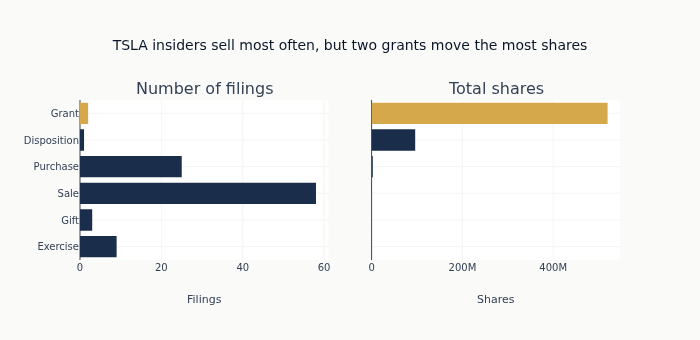

In [12]:
# Highlight the leading (largest-volume) category; keep the rest neutral.
types = summary["transaction_type"].to_list()
bar_colors = [COLORS["amber"] if i == 0 else COLORS["slate"] for i in range(len(types))]

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=("Number of filings", "Total shares"),
    horizontal_spacing=0.08,
)
fig.add_trace(
    go.Bar(y=types, x=summary["count"], orientation="h", marker_color=bar_colors),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(y=types, x=summary["total_shares"], orientation="h", marker_color=bar_colors),
    row=1,
    col=2,
)
fig.update_yaxes(autorange="reversed")
fig.update_xaxes(title_text="Filings", row=1, col=1)
fig.update_xaxes(title_text="Shares", row=1, col=2)
fig.update_layout(
    title="TSLA insiders sell most often, but two grants move the most shares",
    showlegend=False,
    height=340,
)
fig.show()

---
## Part 4: Insider Activity Patterns

We now aggregate open-market purchases (P) and sales (S) by individual insider to see who
is transacting and in what dollar amount.

Form 4 does not always file a price: gifts carry none, and a planned disposition may have
its executed price filed separately. Summing those rows into a dollar total would conflate
priced trades with unreported ones, so we keep them apart: `total_value` is computed only
on rows with a positive price, while `placeholder_trades` and `placeholder_shares` track
any share volume reported without one. Every P/S row in this TSLA sample happens to carry
a price, so the placeholder columns are all zero here — the guard matters on wider
universes, and a silent `shares * price` product would hide the gap when it appears.

In [13]:
market_trades = df.filter(pl.col("code").is_in(["P", "S"]))
priced = pl.col("price") > 0
by_owner = (
    market_trades.group_by(["owner", "transaction_type"])
    .agg(
        pl.len().alias("trades"),
        pl.col("shares").sum().alias("total_shares"),
        pl.when(priced)
        .then(pl.col("shares") * pl.col("price"))
        .otherwise(0.0)
        .sum()
        .alias("total_value"),
        (~priced).sum().alias("placeholder_trades"),
        pl.when(~priced).then(pl.col("shares")).otherwise(0.0).sum().alias("placeholder_shares"),
    )
    .sort("total_value", descending=True)
)
by_owner

owner,transaction_type,trades,total_shares,total_value,placeholder_trades,placeholder_shares
str,str,u32,f64,f64,u32,f64
"""Musk Elon""","""Purchase""",25,2.568732e6,9.9996e8,0,0.0
"""MURDOCH JAMES R""","""Sale""",24,240000.0,9.4119e7,0,0.0
"""Musk Kimbal""","""Sale""",1,56820.0,2.5607e7,0,0.0
"""Wilson-Thompson Kathleen""","""Sale""",22,51540.0,1.9967e7,0,0.0
"""Zhu Xiaotong""","""Sale""",1,20000.0,7.2751e6,0,0.0
"""Taneja Vaibhav""","""Sale""",10,13507.0,4.7594e6,0,0.0


Charting the priced dollar value per insider makes the asymmetry unmistakable: a single
buyer accounts for essentially all of the open-market purchase value ($1.0B), while the
sellers - even added together - transact roughly a sixth of that. Bars are colored by
direction.

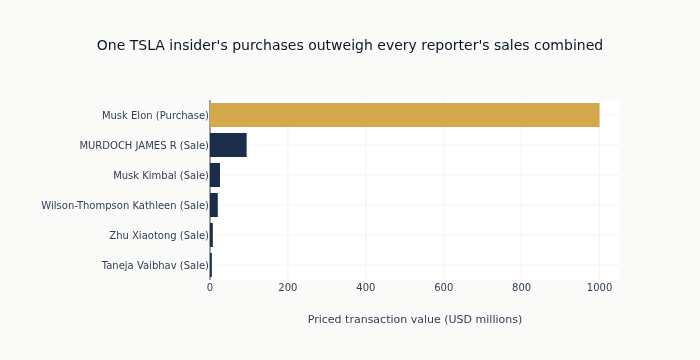

In [14]:
# One horizontal bar per insider, ordered by priced dollar value, colored by direction.
labels = [f"{o} ({t})" for o, t in zip(by_owner["owner"], by_owner["transaction_type"])]
value_colors = [
    COLORS["amber"] if t == "Purchase" else COLORS["slate"] for t in by_owner["transaction_type"]
]

fig = go.Figure(
    go.Bar(
        y=labels,
        x=by_owner["total_value"] / 1e6,
        orientation="h",
        marker_color=value_colors,
    )
)
fig.update_yaxes(autorange="reversed")
fig.update_layout(
    title="One TSLA insider's purchases outweigh every reporter's sales combined",
    xaxis_title="Priced transaction value (USD millions)",
    height=360,
    margin=dict(l=210),
)
fig.show()

---
## Key Takeaways

1. Form 4 filings are XML documents with a small, stable schema (`issuerName`, `rptOwnerName`, `officerTitle`, and one or more transaction blocks). Parse them with an XML parser and iterate over the `<nonDerivativeTransaction>` blocks: the block is the unit that keeps code, date, shares, and price attached to the same trade, and it is what separates common stock from the options in `<derivativeTable>`. A document-wide regex has no such boundaries and will silently interleave fields across trades.
2. The transaction-code dictionary is the load-bearing piece: open-market purchases (P) and sales (S) are the only signals tied directly to insider conviction; option exercises (M/X), grants (A), tax payments (F), and gifts (G) are noise unless explicitly modelled. The share-volume panel makes the point concretely — the two biggest bars are a grant and a disposition, neither of which reflects a view on price.
3. Aggregating by insider × transaction type surfaces the dollar-weighted activity pattern — in the TSLA sample, Elon Musk's 25 purchases ($1.0B) dwarf the cumulative selling activity of every other reporter (~$152M).
4. **For ML features**: net insider buying/selling ratio, purchase-to-sale dollar ratio, and cluster detection (multiple insiders transacting together) are the natural primitives built on top of this DataFrame.
5. For interactive single-company workflows, prefer EdgarTools ([`02_sec_filing_explorer`](02_sec_filing_explorer.ipynb)); use the bulk download path here when scaling to many issuers.